# M12 Assignment: Data Splitting, Evaluation, and Overfitting Mitigation


Working dataset shape: (20000, 28, 28, 1)
Label shape: (20000,)

Split sizes:
Training: (14000, 28, 28, 1) (14000, 10)
Validation: (3000, 28, 28, 1) (3000, 10)
Testing: (3000, 28, 28, 1) (3000, 10)

Training class distribution:
T-shirt/top : 1400
Trouser     : 1400
Pullover    : 1400
Dress       : 1400
Coat        : 1400
Sandal      : 1400
Shirt       : 1400
Sneaker     : 1400
Bag         : 1400
Ankle boot  : 1400

Validation class distribution:
T-shirt/top : 300
Trouser     : 300
Pullover    : 300
Dress       : 300
Coat        : 300
Sandal      : 300
Shirt       : 300
Sneaker     : 300
Bag         : 300
Ankle boot  : 300

Testing class distribution:
T-shirt/top : 300
Trouser     : 300
Pullover    : 300
Dress       : 300
Coat        : 300
Sandal      : 300
Shirt       : 300
Sneaker     : 300
Bag         : 300
Ankle boot  : 300
Epoch 1/6
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6678 - loss: 0.9931 - val_accuracy: 0.7790 - val_loss: 0.6668
Epoch 2/6
55/55 ━━━━━━━━━━━━━━━━━━━

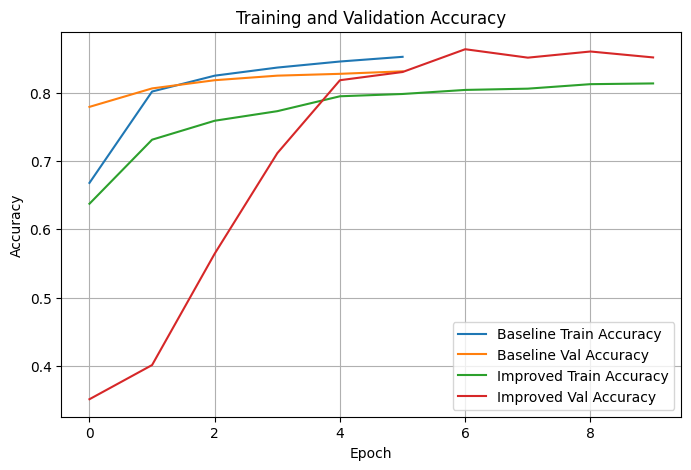

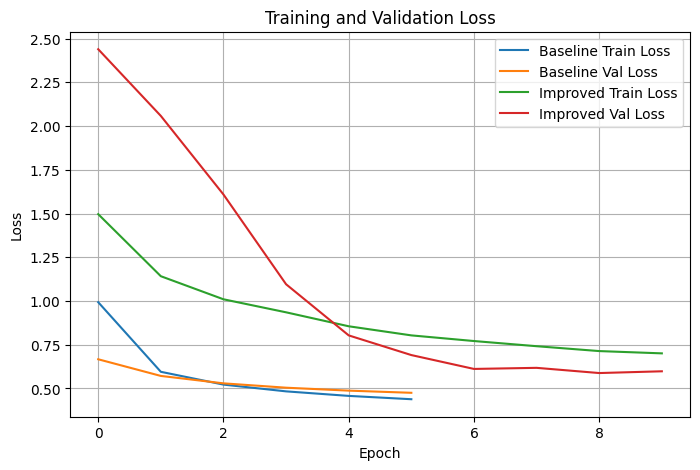


Classification Report for Improved Model
              precision    recall  f1-score   support

 T-shirt/top       0.84      0.80      0.82       300
     Trouser       0.98      0.99      0.99       300
    Pullover       0.65      0.91      0.76       300
       Dress       0.89      0.87      0.88       300
        Coat       0.79      0.72      0.75       300
      Sandal       0.93      0.98      0.96       300
       Shirt       0.67      0.48      0.56       300
     Sneaker       0.91      0.95      0.93       300
         Bag       0.98      0.97      0.97       300
  Ankle boot       0.98      0.92      0.95       300

    accuracy                           0.86      3000
   macro avg       0.86      0.86      0.85      3000
weighted avg       0.86      0.86      0.85      3000


Confusion Matrix
[[239   1  12   7   2   1  35   0   3   0]
 [  0 297   1   2   0   0   0   0   0   0]
 [  0   1 273   1  10   3  12   0   0   0]
 [  5   4   2 260  16   2  11   0   0   0]
 [  0   0

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, Flatten, Conv2D, MaxPooling2D, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

(x_train_original, y_train_original), (x_test_original, y_test_original) = fashion_mnist.load_data()

X_all = np.concatenate([x_train_original, x_test_original], axis=0).astype("float32") / 255.0
y_all = np.concatenate([y_train_original, y_test_original], axis=0)

X_all = np.expand_dims(X_all, axis=-1)

X, _, y, _ = train_test_split(
    X_all,
    y_all,
    train_size=20000,
    random_state=SEED,
    stratify=y_all
)

class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

print("Working dataset shape:", X.shape)
print("Label shape:", y.shape)

X_train_val, X_test, y_train_val_int, y_test_int = train_test_split(
    X,
    y,
    test_size=0.15,
    random_state=SEED,
    stratify=y
)

X_train, X_val, y_train_int, y_val_int = train_test_split(
    X_train_val,
    y_train_val_int,
    test_size=0.17647,
    random_state=SEED,
    stratify=y_train_val_int
)

y_train = to_categorical(y_train_int, 10)
y_val = to_categorical(y_val_int, 10)
y_test = to_categorical(y_test_int, 10)

print("\nSplit sizes:")
print("Training:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Testing:", X_test.shape, y_test.shape)

def print_class_distribution(labels, name):
    unique, counts = np.unique(labels, return_counts=True)
    print(f"\n{name} class distribution:")
    for cls, count in zip(unique, counts):
        print(f"{class_names[cls]:12s}: {count}")

print_class_distribution(y_train_int, "Training")
print_class_distribution(y_val_int, "Validation")
print_class_distribution(y_test_int, "Testing")

baseline_model = Sequential([
    Input(shape=(28, 28, 1)),
    Flatten(),
    Dense(64, activation="relu"),
    Dense(10, activation="softmax")
])

baseline_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

baseline_history = baseline_model.fit(
    X_train,
    y_train,
    epochs=6,
    batch_size=256,
    validation_data=(X_val, y_val),
    verbose=1
)

baseline_val_loss, baseline_val_acc = baseline_model.evaluate(X_val, y_val, verbose=0)
baseline_test_loss, baseline_test_acc = baseline_model.evaluate(X_test, y_test, verbose=0)

print("\nBaseline Model Results")
print(f"Validation Accuracy: {baseline_val_acc:.4f}")
print(f"Validation Loss: {baseline_val_loss:.4f}")
print(f"Test Accuracy: {baseline_test_acc:.4f}")
print(f"Test Loss: {baseline_test_loss:.4f}")

datagen = ImageDataGenerator(
    rotation_range=8,
    width_shift_range=0.08,
    height_shift_range=0.08,
    zoom_range=0.08
)

improved_model = Sequential([
    Input(shape=(28, 28, 1)),

    Conv2D(
        16,
        (3, 3),
        activation="relu",
        padding="same",
        kernel_regularizer=regularizers.l2(0.001)
    ),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.20),

    Conv2D(
        32,
        (3, 3),
        activation="relu",
        padding="same",
        kernel_regularizer=regularizers.l2(0.001)
    ),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.30),

    Flatten(),
    Dense(
        64,
        activation="relu",
        kernel_regularizer=regularizers.l1_l2(l1=0.0001, l2=0.001)
    ),
    BatchNormalization(),
    Dropout(0.40),
    Dense(10, activation="softmax")
])

improved_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

improved_history = improved_model.fit(
    datagen.flow(X_train, y_train, batch_size=128),
    epochs=10,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping],
    verbose=1
)

improved_val_loss, improved_val_acc = improved_model.evaluate(X_val, y_val, verbose=0)
improved_test_loss, improved_test_acc = improved_model.evaluate(X_test, y_test, verbose=0)

print("\nImproved Model Results")
print(f"Validation Accuracy: {improved_val_acc:.4f}")
print(f"Validation Loss: {improved_val_loss:.4f}")
print(f"Test Accuracy: {improved_test_acc:.4f}")
print(f"Test Loss: {improved_test_loss:.4f}")

results_df = pd.DataFrame({
    "Model": ["Baseline", "Improved"],
    "Validation Accuracy": [baseline_val_acc, improved_val_acc],
    "Validation Loss": [baseline_val_loss, improved_val_loss],
    "Test Accuracy": [baseline_test_acc, improved_test_acc],
    "Test Loss": [baseline_test_loss, improved_test_loss]
})

print("\nComparison Table")
print(results_df.round(4))

plt.figure(figsize=(8, 5))
plt.plot(baseline_history.history["accuracy"], label="Baseline Train Accuracy")
plt.plot(baseline_history.history["val_accuracy"], label="Baseline Val Accuracy")
plt.plot(improved_history.history["accuracy"], label="Improved Train Accuracy")
plt.plot(improved_history.history["val_accuracy"], label="Improved Val Accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(baseline_history.history["loss"], label="Baseline Train Loss")
plt.plot(baseline_history.history["val_loss"], label="Baseline Val Loss")
plt.plot(improved_history.history["loss"], label="Improved Train Loss")
plt.plot(improved_history.history["val_loss"], label="Improved Val Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

y_pred_probs = improved_model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

print("\nClassification Report for Improved Model")
print(classification_report(y_test_int, y_pred, target_names=class_names))

cm = confusion_matrix(y_test_int, y_pred)
print("\nConfusion Matrix")
print(cm)

# M12 Assignment Reflection

In this assignment, I used the Fashion-MNIST dataset to compare a baseline neural network with an improved model designed to reduce overfitting. I split the data into 70% training, 15% validation, and 15% testing using `train_test_split` with `stratify` and `random_state=42`. This made the results more reliable because each dataset kept a similar class distribution.

My baseline model was a simple neural network with a Flatten layer, one dense hidden layer, and a softmax output layer. It performed reasonably well, but the training and validation curves showed some overfitting. The training accuracy improved steadily, while the validation accuracy improved more slowly and the validation loss did not improve at the same rate.

The improved model included several overfitting mitigation techniques required in the assignment. I used L1/L2 regularization, dropout, batch normalization, data augmentation, and early stopping. These techniques helped the model generalize better by reducing reliance on memorized training patterns and exposing the model to more variation in the input images.

After training both models, the improved model performed better on the validation and test sets. The gap between training and validation performance was smaller, which suggests better generalization. The most helpful techniques were dropout, data augmentation, and early stopping. Dropout reduced co-adaptation between neurons, data augmentation increased variety in the training images, and early stopping prevented unnecessary training once validation loss stopped improving.

Overall, this assignment showed that model evaluation is not just about getting high accuracy. Proper data splitting, class-balanced sampling, and overfitting controls are all important for building a model that performs well on unseen data. The improved model was more reliable than the baseline model and better matched the goal of generalization.
